Gitlab: https://git.imp.fu-berlin.de/kunaphak91/ifabi-2019

Name  
  1. Minie Jung
  2. Kunaphas Kongkitimanon
  3. Chang Wan-Ju


# 1,000 Genome Data Stories with GoogleCloud BigQuery
The following sections demonstrate some interactive exploration within the 1,000 Genomes data set.

Getting Familiar with the Data
* Exploring the sample information data
* Exploring the variant data
* Understanding Alternate Alleles in 1,000 Genomes

Comparisons to Common Tools and Research Results
* Reproducing the output of vcfstats for BRCA1 in 1,000 Genomes
* Reproducing 1,000 Genomes allele frequencies for variants in BRCA1
* Reproducing the Hardy-Weinberg Equilibrium test for BRCA1 in 1,000 Genomes

# Before you begin


1.   Use the [Cloud Resource Manager](https://console.cloud.google.com/cloud-resource-manager) to Create a Cloud Platform project if you do not already have one.
2.   [Enable billing](https://support.google.com/cloud/answer/6293499#enable-billing) for the project.
3.   [Enable BigQuery](https://console.cloud.google.com/flows/enableapi?apiid=bigquery) APIs for the project.


In [0]:
import pandas as pd
import time

from google.cloud import bigquery

# Set use_legacy_sql to True to use legacy SQL syntax.
job_config = bigquery.QueryJobConfig()
job_config.use_legacy_sql = True

class BigQueryHelper(object):
    """
    Helper class to simplify common BigQuery tasks like executing queries,
    showing table schemas, etc without worrying about table or dataset pointers.

    See the BigQuery docs for details of the steps this class lets you skip:
    https://googlecloudplatform.github.io/google-cloud-python/latest/bigquery/reference.html
    """

    def __init__(self, active_project, dataset_name, max_wait_seconds=180):
        self.project_name = active_project
        self.dataset_name = dataset_name
        self.max_wait_seconds = max_wait_seconds
        self.client = bigquery.Client()
        self.__dataset_ref = self.client.dataset(self.dataset_name, project=self.project_name)
        self.dataset = None
        self.tables = dict()  # {table name (str): table object}
        self.__table_refs = dict()  # {table name (str): table reference}
        self.total_gb_used_net_cache = 0
        self.BYTES_PER_GB = 2**30

    def __fetch_dataset(self):
        """
        Lazy loading of dataset. For example,
        if the user only calls `self.query_to_pandas` then the
        dataset never has to be fetched.
        """
        if self.dataset is None:
            self.dataset = self.client.get_dataset(self.__dataset_ref)

    def __fetch_table(self, table_name):
        """
        Lazy loading of table
        """
        self.__fetch_dataset()
        if table_name not in self.__table_refs:
            self.__table_refs[table_name] = self.dataset.table(table_name)
        if table_name not in self.tables:
            self.tables[table_name] = self.client.get_table(self.__table_refs[table_name])

    def __handle_record_field(self, row, schema_details, top_level_name=''):
        """
        Unpack a single row, including any nested fields.
        """
        name = row['name']
        if top_level_name != '':
            name = top_level_name + '.' + name
        schema_details.append([{
            'name': name,
            'type': row['type'],
            'mode': row['mode'],
            'fields': pd.np.nan,
            'description': row['description']
                               }])
        # float check is to dodge row['fields'] == np.nan
        if type(row.get('fields', 0.0)) == float:
            return None
        for entry in row['fields']:
            self.__handle_record_field(entry, schema_details, name)

    def __unpack_all_schema_fields(self, schema):
        """
        Unrolls nested schemas. Returns dataframe with one row per field,
        and the field names in the format accepted by the API.
        Results will look similar to the website schema, such as:
            https://bigquery.cloud.google.com/table/bigquery-public-data:github_repos.commits?pli=1

        Args:
            schema: DataFrame derived from api repr of raw table.schema
        Returns:
            Dataframe of the unrolled schema.
        """
        schema_details = []
        schema.apply(lambda row:
            self.__handle_record_field(row, schema_details), axis=1)
        result = pd.concat([pd.DataFrame.from_dict(x) for x in schema_details])
        result.reset_index(drop=True, inplace=True)
        del result['fields']
        return result

    def table_schema(self, table_name):
        """
        Get the schema for a specific table from a dataset.
        Unrolls nested field names into the format that can be copied
        directly into queries. For example, for the `github.commits` table,
        the this will return `committer.name`.

        This is a very different return signature than BigQuery's table.schema.
        """
        self.__fetch_table(table_name)
        raw_schema = self.tables[table_name].schema
        schema = pd.DataFrame.from_dict([x.to_api_repr() for x in raw_schema])
        # the api_repr only has the fields column for tables with nested data
        if 'fields' in schema.columns:
            schema = self.__unpack_all_schema_fields(schema)
        # Set the column order
        schema = schema[['name', 'type', 'mode', 'description']]
        return schema

    def list_tables(self):
        """
        List the names of the tables in a dataset
        """
        self.__fetch_dataset()
        return([x.table_id for x in self.client.list_tables(self.dataset)])

    def estimate_query_size(self, query):
        """
        Estimate gigabytes scanned by query.
        Does not consider if there is a cached query table.
        See https://cloud.google.com/bigquery/docs/reference/rest/v2/jobs#configuration.dryRun
        """
        my_job_config = bigquery.job.QueryJobConfig()
        my_job_config.dry_run = True
        my_job = self.client.query(query, job_config=my_job_config)
        return my_job.total_bytes_processed / self.BYTES_PER_GB

    def query_to_pandas(self, query):
        """
        Execute a SQL query & return a pandas dataframe
        """
        my_job = self.client.query(query)
        start_time = time.time()
        while not my_job.done():
            if (time.time() - start_time) > self.max_wait_seconds:
                print("Max wait time elapsed, query cancelled.")
                self.client.cancel_job(my_job.job_id)
                return None
            time.sleep(0.1)
        # Queries that hit errors will return an exception type.
        # Those exceptions don't get raised until we call my_job.to_dataframe()
        # In that case, my_job.total_bytes_billed can be called but is None
        if my_job.total_bytes_billed:
            self.total_gb_used_net_cache += my_job.total_bytes_billed / self.BYTES_PER_GB
        return my_job.to_dataframe()

    def query_to_pandas_safe(self, query, max_gb_scanned=1):
        """
        Execute a query, but only if the query would scan less than `max_gb_scanned` of data.
        """
        query_size = self.estimate_query_size(query)
        if query_size <= max_gb_scanned:
            return self.query_to_pandas(query)
        msg = "Query cancelled; estimated size of {0} exceeds limit of {1} GB"
        print(msg.format(query_size, max_gb_scanned))

    def head(self, table_name, num_rows=5, start_index=None, selected_columns=None):
        """
        Get the first n rows of a table as a DataFrame.
        Does not perform a full table scan; should use a trivial amount of data as long as n is small.
        """
        self.__fetch_table(table_name)
        active_table = self.tables[table_name]
        schema_subset = None
        if selected_columns:
            schema_subset = [col for col in active_table.schema if col.name in selected_columns]
        results = self.client.list_rows(active_table, selected_fields=schema_subset,
            max_results=num_rows, start_index=start_index)
        results = [x for x in results]
        return pd.DataFrame(
            data=[list(x.values()) for x in results], columns=list(results[0].keys()))

### Provide your credentials to the runtime

In [2]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


## Optional: Enable data table display

Colab includes the ``google.colab.data_table`` package that can be used to display large pandas dataframes as an interactive data table.
It can be enabled with:

In [0]:
%load_ext google.colab.data_table

If you would prefer to return to the classic Pandas dataframe display, you can disable this by running:
```python
%unload_ext google.colab.data_table
```

In [0]:
project_id = 'pilotwgs'

In [0]:
%env GCLOUD_PROJECT=pilotwgs

env: GCLOUD_PROJECT=pilotwgs


In [0]:
from google.cloud import bigquery

client = bigquery.Client(project=project_id)


In [0]:
bq_assistant = BigQueryHelper("bigquery-public-data", "github_repos")

 # Getting Familiar with the Data

In [0]:
# Matplotlib for additional customization
from matplotlib import pyplot as plt
%matplotlib inline

# Seaborn for plotting and styling
import seaborn as sns
type_colors = ['#78C850',  # Grass
                    '#F08030',  # Fire
                    '#6890F0',  # Water
                    '#A8B820',  # Bug
                    '#A8A878',  # Normal
                    '#A040A0',  # Poison
                    '#F8D030',  # Electric
                    '#E0C068',  # Ground
                    '#EE99AC',  # Fairy
                    '#C03028',  # Fighting
                    '#F85888',  # Psychic
                    '#B8A038',  # Rock
                    '#705898',  # Ghost
                    '#98D8D8',  # Ice
                    '#7038F8',  # Dragon
                   ]
def bq_dryRUN(QUERY):
    job_config = bigquery.QueryJobConfig()
    job_config.dry_run = True
    job_config.use_query_cache = False
    job_config.use_legacy_sql = True
    query_job = client.query(
        QUERY,
        # Location must match that of the dataset(s) referenced in the query.
        location="US",
        job_config=job_config,
    )  # API request

    # A dry run query completes immediately.
    assert query_job.state == "DONE"
    assert query_job.dry_run

    print("This query will process {} bytes.".format(query_job.total_bytes_processed))

## Exploring the sample information data

### Samples Vs SampleinVariantsTable

In [0]:
QUERY = """
# Count the number of samples in the phenotypic data
SELECT
   COUNT(sample) AS all_samples,
   SUM(IF(In_Phase1_Integrated_Variant_Set = TRUE, 1, 0)) AS samples_in_variants_table
FROM
   `genomics-public-data.1000_genomes.sample_info` 
   """
   
bq_assistant.estimate_query_size(QUERY)

3.0353665351867676e-05

In [0]:
df = client.query(QUERY).to_dataframe()
df

,all_samples,samples_in_variants_table
0,3500,1092


### Gender ratio

In [0]:
QUERY = """
# Compute sample count and ratio by gender
SELECT
  gender,
  gender_count,
  RATIO_TO_REPORT(gender_count)
OVER
  (
  ORDER BY
    gender_count) AS gender_ratio
FROM (
  SELECT
    gender,
    COUNT(gender) AS gender_count,
  FROM
    [genomics-public-data:1000_genomes.sample_info]
  WHERE
    In_Phase1_Integrated_Variant_Set = TRUE
  GROUP BY
    gender)
   """

In [0]:
bq_dryRUN(QUERY)
df = client.query(QUERY, job_config=bigquery.QueryJobConfig(use_legacy_sql=True)).to_dataframe()
df

This query will process 25612 bytes.


,gender,gender_count,gender_ratio
0,male,525,0.480769
1,female,567,0.519231


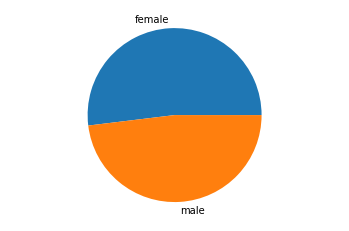

In [0]:
sums = df.gender_count.groupby(df.gender).sum()
plt.axis('equal');
plt.pie(sums, labels=sums.index);
plt.show()

### Ethnicity ratio

In [0]:
QUERY = """
# Compute sample count and ratio by ethnicity
SELECT
  population,
  population_description,
  population_count,
  RATIO_TO_REPORT(population_count)
OVER
  (
  ORDER BY
    population_count) AS population_ratio,
  super_population,
  super_population_description,
from(
  SELECT
    population,
    population_description,
    super_population,
    super_population_description,
    COUNT(population) AS population_count,
  FROM
    [genomics-public-data:1000_genomes.sample_info]
  WHERE
    In_Phase1_Integrated_Variant_Set = TRUE
  GROUP BY
    population,
    population_description,
    super_population,
    super_population_description)
     """
bq_dryRUN(QUERY)

This query will process 179714 bytes.


In [0]:
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,population,population_description,population_count,population_ratio,super_population,super_population_description
0,IBS,Iberian populations in Spain,14,0.012821,EUR,European
1,PUR,Puerto Rican in Puerto Rico,55,0.050366,AMR,American
2,CLM,"Colombian in Medellin, Colombia",60,0.054945,AMR,American
3,ASW,African Ancestry in Southwest US,61,0.055861,AFR,African
4,MXL,"Mexican Ancestry in Los Angeles, California",66,0.060440,AMR,American
5,CEU,Utah residents with Northern and Western Europ...,85,0.077839,EUR,European
6,YRI,"Yoruba in Ibadan, Nigeria",88,0.080586,AFR,African
7,GBR,British in England and Scotland,89,0.081502,EUR,European
8,JPT,"Japanese in Tokyo, Japan",89,0.081502,EAS,East Asian
9,FIN,Finnish in Finland,93,0.085165,EUR,European


### Ethnicities grouped by super population

In [0]:
QUERY = """
# Ratios of ethnicities grouped by super population
SELECT
  super_population,
  super_population_description,
  super_population_count,
  RATIO_TO_REPORT(super_population_count)
OVER
  (
  ORDER BY
    super_population_count) AS super_population_ratio
from(
  SELECT
    super_population,
    super_population_description,
    COUNT(population) AS super_population_count
  FROM
    [genomics-public-data:1000_genomes.sample_info]
  WHERE
    In_Phase1_Integrated_Variant_Set = TRUE
  GROUP BY
    super_population,
    super_population_description)
 """
bq_dryRUN(QUERY)

This query will process 73291 bytes.


In [0]:
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,super_population,super_population_description,super_population_count,super_population_ratio
0,AMR,American,181,0.165751
1,AFR,African,246,0.225275
2,EAS,East Asian,286,0.261905
3,EUR,European,379,0.347070


(array([0, 1, 2, 3]), <a list of 4 Text xticklabel objects>)

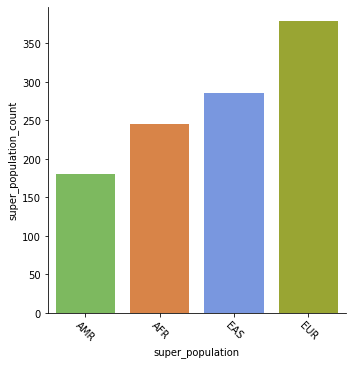

In [0]:
# Count Plot (a.k.a. Bar Plot)
sns.catplot(x='super_population',y='super_population_count', data=df, palette=type_colors, kind="bar")
 
# Rotate x-labels
plt.xticks(rotation=-45)

###  Distribution of family sizes

In [0]:
QUERY = """
# Compute the distribution of family sizes
SELECT
num_family_members AS family_size,
COUNT(num_family_members) AS num_families_of_size
FROM (
  SELECT
  family_id,
  COUNT(family_id) AS num_family_members,
  FROM
  [genomics-public-data:1000_genomes.sample_info]
  WHERE
  In_Phase1_Integrated_Variant_Set = TRUE
  GROUP BY
  family_id)
GROUP BY
family_size
 """
bq_dryRUN(QUERY)

This query will process 26072 bytes.


In [0]:
df = client.query(QUERY, job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,family_size,num_families_of_size
0,1,636
1,2,204
2,3,12
3,4,3


## Basic Plots of 1k Genome Data

####Min/Max Chromosomal Positions of Variants

In [0]:
QUERY = """
SELECT
   INTEGER(reference_name) AS chromosome,
   MIN(start) AS min,
   MAX(start) AS max
 FROM
   [genomics-public-data:1000_genomes.variants]
 OMIT RECORD IF
   reference_name IN ("X", "Y", "MT")
 GROUP BY
   chromosome
   """
bq_dryRUN(QUERY)

This query will process 452412012 bytes.


In [0]:
QUERY = """
SELECT
   INTEGER(reference_name) AS chromosome,
   MIN(start) AS min,
   MAX(start) AS max
 FROM
   [genomics-public-data:1000_genomes.variants]
 OMIT RECORD IF
   reference_name IN ("X", "Y", "MT")
 GROUP BY
   chromosome
   """
df = client.query(QUERY, job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,chromosome,min,max
0,11,70854,134946450
1,5,11939,180885154
2,21,9411242,48119750
3,16,60053,90292810
4,13,19020012,115109851
5,20,60478,62965161
6,8,10421,146303865
7,2,10132,243188918
8,7,16160,159128573
9,1,10582,249239464


####Frequency of Variant Types Per Chromosome

In [0]:
QUERY = """
SELECT
  INTEGER(reference_name) AS chromosome,
  vt AS variant_type,
  COUNT(1) AS cnt
 FROM
   [genomics-public-data:1000_genomes.variants]
 OMIT RECORD IF
   reference_name IN ("X", "Y", "MT")
 GROUP BY
   chromosome,
   variant_type
   """
bq_dryRUN(QUERY)


This query will process 335991977 bytes.


In [0]:
df = client.query(QUERY, job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,chromosome,variant_type,cnt
0,6,INDEL,92844
1,15,INDEL,41178
2,18,SV,395
3,11,SV,724
4,5,SNP,2438833
...,...,...,...
61,21,SV,165
62,6,SNP,2330731
63,9,SNP,1594481
64,1,SNP,2896960


####Types of SNP pairs (looks at both alleles)

In [0]:
QUERY = """
SELECT
  reference_bases AS reference,
  CONCAT(
    IF(first_allele=0,
       reference_bases,
       alternate_bases),
    "|",
    IF(second_allele=0,
       reference_bases,
       alternate_bases)
    ) AS alleles,
  COUNT(1) AS cnt,
FROM
     FLATTEN((SELECT 
         reference_name,
         reference_bases,
         alternate_bases,
         vt,
         NTH(1, call.genotype) WITHIN call AS first_allele,
         NTH(2, call.genotype) WITHIN call AS second_allele
       FROM [genomics-public-data:1000_genomes.variants])
     , call)
OMIT RECORD IF
     reference_name IN ("X", "Y", "MT")
  OR first_allele < 0
  OR second_allele < 0
  OR vt != "SNP"
GROUP BY
  reference,
  alleles
  """

bq_dryRUN(QUERY)


This query will process 688131025083 bytes.


In [0]:
#print(bq_assistant.estimate_query_size(QUERY))
df = client.query(QUERY, job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,reference,alleles,cnt
0,A,A|G,190193924
1,A,A|C,47649777
2,G,G|T,52164964
3,T,T|C,190350406
4,C,C|G,52163897
5,T,G|T,47380525
6,A,A|T,42098551
7,C,A|C,52251229
8,T,G|G,64481800
9,T,A|A,52008013


####Length of Insertion/Deletion

In [0]:
QUERY = """
SELECT
  CASE
    WHEN LENGTH(alternate_bases) - 
         LENGTH(reference_bases) > 50 
      THEN 51
    WHEN LENGTH(alternate_bases) - 
         LENGTH(reference_bases) < -50 
      THEN -51
    ELSE
      LENGTH(alternate_bases) - 
      LENGTH(reference_bases) 
END AS length,
  COUNT(1) AS cnt
FROM
     FLATTEN((SELECT 
         reference_name,
         reference_bases,
         alternate_bases,
         vt,
         NTH(1, call.genotype) WITHIN call AS first_allele,
         NTH(2, call.genotype) WITHIN call AS second_allele
       FROM [genomics-public-data:1000_genomes.variants])
     , call)
WHERE
      first_allele =
      POSITION(alternate_bases)
  AND LENGTH(alternate_bases) -
      LENGTH(reference_bases) != 0
OMIT RECORD IF
      reference_name IN ("X", "Y", "MT")
  AND vt != "INDEL"
GROUP BY
  length
  """
bq_dryRUN(QUERY)


This query will process 688131025083 bytes.


In [0]:
#print(bq_assistant.estimate_query_size(QUERY))
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

####Quality score of calls (at least, of INDELs)

In [0]:
QUERY = """
SELECT
  vt AS variant_type,
  quality,
  COUNT(1) AS cnt
FROM
  [genomics-public-data:1000_genomes.variants]
OMIT RECORD IF
  reference_name IN ("X", "Y", "MT")
GROUP BY
  variant_type,
  quality
  """
bq_dryRUN(QUERY)

This query will process 519232397 bytes.


In [0]:
QUERY = """
SELECT
  vt AS variant_type,
  quality,
  COUNT(1) AS cnt
FROM
  [genomics-public-data:1000_genomes.variants]
OMIT RECORD IF
  reference_name IN ("X", "Y", "MT")
GROUP BY
  variant_type,
  quality
  """

#print(bq_assistant.estimate_query_size(QUERY))
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,variant_type,quality,cnt
0,INDEL,897.0,230
1,INDEL,218.0,3476
2,INDEL,534.0,1323
3,INDEL,402.0,1261
4,INDEL,560.0,838
...,...,...,...
3462,INDEL,4259.0,1
3463,INDEL,5620.0,1
3464,INDEL,3686.0,1
3465,INDEL,3875.0,1


####Likelihood Scores for each Allele


In [0]:
QUERY = """
SELECT
  variant_type,
  likelihood,
  COUNT(1) AS cnt
FROM (
  SELECT
    variant_type,
    ROUND(100 * IF(gl > -0.5, gl,
          -0.5)) AS likelihood,
  FROM
     FLATTEN((SELECT 
         reference_name,
         vt AS variant_type,
         call.call_set_name AS genome,
         call.phaseset AS phaseset,
         call.genotype_likelihood AS gl,
         NTH(1, call.genotype) WITHIN call AS first_allele,
         NTH(2, call.genotype) WITHIN call AS second_allele
       FROM [genomics-public-data:1000_genomes.variants])
     , call)
  WHERE
        (first_allele <= second_allele
          AND POSITION(gl) = 1 +
          (second_allele *
            (second_allele + 1) / 2) +
          first_allele)
        OR (second_allele < first_allele
          AND POSITION(gl) = 1 +
          (first_allele *
            (first_allele + 1) / 2) +
          second_allele)
  OMIT RECORD IF 
       reference_name in ("X", "Y", "MT")
    OR phaseset IS NULL
)
GROUP BY
  variant_type,
  likelihood
  """
bq_dryRUN(QUERY)


This query will process 1722622324285 bytes.


In [0]:
#print(bq_assistant.estimate_query_size(QUERY))
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

####SNP distribution in Genomes

In [8]:
QUERY = """
SELECT
  variant_info.genome AS genome,
  CONCAT(SUBSTR(sample_info.population_description,
                0, 20), "...") AS population,
  sample_info.super_population_description
                AS super_population,
  SUM(variant_info.single) AS cnt1,
  SUM(variant_info.double) AS cnt2
FROM (
  FLATTEN(
    (
      SELECT 
        call.call_set_name AS genome,
        SOME(call.genotype > 0) AND NOT EVERY(call.genotype > 0) WITHIN call AS single,
        EVERY(call.genotype > 0) WITHIN call AS double,
      FROM [genomics-public-data:1000_genomes.variants]
      OMIT RECORD IF
        reference_name IN ("X", "Y", "MT")
     )
  , call)
  ) AS variant_info
  JOIN
    [genomics-public-data:1000_genomes.sample_info] AS sample_info
  ON
    variant_info.genome = sample_info.sample
GROUP BY
  genome,
  population,
  super_population
  """
bq_dryRUN(QUERY)


This query will process 1078176758498 bytes.


In [0]:
#print(bq_assistant.estimate_query_size(QUERY))
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

## Understanding Alternate Alleles in 1,000 Genomes VCF Data

### Is (reference_name, start, reference_bases) a unique key in the 1,000 Genomes Data?

In [0]:
# Find variants on chromosome 17 that reside on the same start with the same reference base
QUERY = """
SELECT
  reference_name,
  start,
  reference_bases,
  COUNT(start) AS num_alternates
FROM
  [genomics-public-data:1000_genomes.variants]
WHERE
  reference_name = '17'
GROUP BY
  reference_name,
  start,
  reference_bases
HAVING
  num_alternates > 1
ORDER BY
  reference_name,
  start,
  reference_bases
  """
bq_dryRUN(QUERY)

This query will process 640152948 bytes.


In [0]:
# Find variants on chromosome 17 that reside on the same start with the same reference base
QUERY = """
SELECT
  reference_name,
  start,
  reference_bases,
  COUNT(start) AS num_alternates
FROM
  [genomics-public-data:1000_genomes.variants]
WHERE
  reference_name = '17'
GROUP BY
  reference_name,
  start,
  reference_bases
HAVING
  num_alternates > 1
ORDER BY
  reference_name,
  start,
  reference_bases
  """

#print(bq_assistant.estimate_query_size(QUERY))
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,reference_name,start,reference_bases,num_alternates
0,17,184672,G,2
1,17,211031,C,2
2,17,240039,G,2
3,17,443435,A,2
4,17,533535,A,2
...,...,...,...,...
412,17,78648088,G,2
413,17,79186131,A,2
414,17,79807705,A,2
415,17,80565079,A,2


### Alternate alleles

In [0]:
QUERY = """
# Get three particular start on chromosome 17 that have alternate variants.
SELECT
  reference_name,
  start,
  reference_bases,
  GROUP_CONCAT(alternate_bases) WITHIN RECORD AS alt,
  GROUP_CONCAT(names) WITHIN RECORD AS names,
  vt,
FROM
  [genomics-public-data:1000_genomes.variants]
WHERE
  reference_name = '17'
  AND (start = 48515942
    OR start = 48570613
    OR start = 48659342)
ORDER BY
  start,
  reference_bases,
  alt
    """  
bq_dryRUN(QUERY)

This query will process 1957786520 bytes.


In [0]:
QUERY = """
# Get three particular start on chromosome 17 that have alternate variants.
SELECT
  reference_name,
  start,
  reference_bases,
  GROUP_CONCAT(alternate_bases) WITHIN RECORD AS alt,
  GROUP_CONCAT(names) WITHIN RECORD AS names,
  vt,
FROM
  [genomics-public-data:1000_genomes.variants]
WHERE
  reference_name = '17'
  AND (start = 48515942
    OR start = 48570613
    OR start = 48659342)
ORDER BY
  start,
  reference_bases,
  alt
    """    
#print(bq_assistant.estimate_query_size(QUERY))
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,reference_name,start,reference_bases,alt,names,vt
0,17,48515942,T,G,"rs8076712,rs8076712",SNP
1,17,48515942,T,TG,"rs113432301,rs113432301",INDEL
2,17,48570613,A,AT,"rs201827568,rs201827568",INDEL
3,17,48570613,A,T,"rs9896330,rs9896330",SNP
4,17,48659342,C,CTGGT,"rs148905490,rs148905490",INDEL
5,17,48659342,C,T,"rs113983760,rs113983760",SNP


### A unique (reference_name, start, reference_bases) tuple, are the variants always SNPs?

In [0]:
QUERY= """
# Count by variant type the number of variants on chromosome 17 unique for a
# start and reference base
SELECT
  vt,
  COUNT(vt) AS num_variant_type
FROM
  [genomics-public-data:1000_genomes.variants] AS variants
JOIN EACH (
  SELECT
    reference_name,
    start,
    reference_bases,
    COUNT(start) AS num_alternates
  FROM
    [genomics-public-data:1000_genomes.variants]
  WHERE
    reference_name = '17'
  GROUP EACH BY
    reference_name,
    start,
    reference_bases
  HAVING
    num_alternates = 1) AS singles
ON
  variants.reference_name = singles.reference_name
  AND variants.start = singles.start
  AND variants.reference_bases = singles.reference_bases
WHERE
  variants.reference_name = '17'
GROUP EACH BY
  vt
ORDER BY
  vt
"""
bq_dryRUN(QUERY)

This query will process 841559129 bytes.


In [0]:
QUERY= """
# Count by variant type the number of variants on chromosome 17 unique for a
# start and reference base
SELECT
  vt,
  COUNT(vt) AS num_variant_type
FROM
  [genomics-public-data:1000_genomes.variants] AS variants
JOIN EACH (
  SELECT
    reference_name,
    start,
    reference_bases,
    COUNT(start) AS num_alternates
  FROM
    [genomics-public-data:1000_genomes.variants]
  WHERE
    reference_name = '17'
  GROUP EACH BY
    reference_name,
    start,
    reference_bases
  HAVING
    num_alternates = 1) AS singles
ON
  variants.reference_name = singles.reference_name
  AND variants.start = singles.start
  AND variants.reference_bases = singles.reference_bases
WHERE
  variants.reference_name = '17'
GROUP EACH BY
  vt
ORDER BY
  vt
"""

#print(bq_assistant.estimate_query_size(QUERY))
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,vt,num_variant_type
0,INDEL,38754
1,SNP,1006702
2,SV,443


# Comparisons to Common Tools and Research Results

## Reproducing the output of vcfstats


### How many private variants each sample has.

In [7]:
QUERY = """
# Compute the number of variants within BRCA1 for a particular sample that are shared by
# no other samples.
SELECT
  COUNT(sample_id) AS private_variants_count,
  sample_id
FROM
  (
  SELECT
    reference_name,
    start,
    reference_bases,
    IF(0 < call.genotype,
      call.call_set_name,
      NULL) AS sample_id,
    SUM(IF(0 < call.genotype,
        1,
        0)) WITHIN RECORD AS num_samples_with_variant
  FROM
    [genomics-public-data:1000_genomes.variants]
  WHERE
    reference_name = '17'
    AND start BETWEEN 41196311
    AND 41277499
  HAVING
    num_samples_with_variant = 1
    AND sample_id IS NOT NULL)
GROUP EACH BY
  sample_id
ORDER BY
  sample_id
  """
bq_dryRUN(QUERY)

This query will process 1078628995388 bytes.


In [0]:
QUERY = """
# Compute the number of variants within BRCA1 for a particular sample that are shared by
# no other samples.
SELECT
  COUNT(sample_id) AS private_variants_count,
  sample_id
FROM
  (
  SELECT
    reference_name,
    start,
    reference_bases,
    IF(0 < call.genotype,
      call.call_set_name,
      NULL) AS sample_id,
    SUM(IF(0 < call.genotype,
        1,
        0)) WITHIN RECORD AS num_samples_with_variant
  FROM
    [genomics-public-data:1000_genomes.variants]
  WHERE
    reference_name = '17'
    AND start BETWEEN 41196311
    AND 41277499
  HAVING
    num_samples_with_variant = 1
    AND sample_id IS NOT NULL)
GROUP EACH BY
  sample_id
ORDER BY
  sample_id
  """
  #print(bq_assistant.estimate_query_size(QUERY))
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,private_variants_count,sample_id
0,1,HG00106
1,1,HG00109
2,1,HG00143
3,3,HG00152
4,1,HG00160
...,...,...
182,1,NA20803
183,1,NA20805
184,1,NA20809
185,2,NA20819


## Reproducing Allelic Frequencies

### Computes the frequency of both the reference and alternate SNPs within BRCA1 for all samples within 1,000 Genomes.

In [0]:
QUERY = """
# The following query computes the allelic frequency for BRCA1 variants in the
# 1,000 Genomes dataset and also includes the pre-computed value from the dataset.
SELECT
  reference_name,
  start,
  reference_bases,
  alternate_bases,
  SUM(ref_count)+SUM(alt_count) AS num_sample_alleles,
  SUM(ref_count) AS ref_cnt,
  SUM(alt_count) AS alt_cnt,
  SUM(ref_count)/(SUM(ref_count)+SUM(alt_count)) AS ref_freq,
  SUM(alt_count)/(SUM(ref_count)+SUM(alt_count)) AS alt_freq,
  alt_freq_from_1KG
FROM (
  SELECT
    reference_name,
    start,
    reference_bases,
    alternate_bases,
    alt,
    SUM(INTEGER(0 = call.genotype)) WITHIN RECORD AS ref_count,
    SUM(INTEGER(alt = call.genotype)) WITHIN RECORD AS alt_count,
    alt_freq_from_1KG
  FROM
    FLATTEN(
      FLATTEN((
        SELECT
          reference_name,
          start,
          reference_bases,
          alternate_bases,
          POSITION(alternate_bases) AS alt,
          af AS alt_freq_from_1KG,
          call.call_set_name,
          call.genotype,
        FROM
          [genomics-public-data:1000_genomes.variants]
        WHERE
          reference_name = '17'
          AND start BETWEEN 41196311
          AND 41277499
          AND vt='SNP'
          ),
        call),
      alt))
GROUP BY
  reference_name,
  start,
  reference_bases,
  alternate_bases,
  alt,
  alt_freq_from_1KG
ORDER BY
  reference_name,
  start,
  reference_bases,
  alt,
  alternate_bases
    """
bq_dryRUN(QUERY)

This query will process 689102496996 bytes.


In [0]:
QUERY = """
# The following query computes the allelic frequency for BRCA1 variants in the
# 1,000 Genomes dataset and also includes the pre-computed value from the dataset.
SELECT
  reference_name,
  start,
  reference_bases,
  alternate_bases,
  SUM(ref_count)+SUM(alt_count) AS num_sample_alleles,
  SUM(ref_count) AS ref_cnt,
  SUM(alt_count) AS alt_cnt,
  SUM(ref_count)/(SUM(ref_count)+SUM(alt_count)) AS ref_freq,
  SUM(alt_count)/(SUM(ref_count)+SUM(alt_count)) AS alt_freq,
  alt_freq_from_1KG
FROM (
  SELECT
    reference_name,
    start,
    reference_bases,
    alternate_bases,
    alt,
    SUM(INTEGER(0 = call.genotype)) WITHIN RECORD AS ref_count,
    SUM(INTEGER(alt = call.genotype)) WITHIN RECORD AS alt_count,
    alt_freq_from_1KG
  FROM
    FLATTEN(
      FLATTEN((
        SELECT
          reference_name,
          start,
          reference_bases,
          alternate_bases,
          POSITION(alternate_bases) AS alt,
          af AS alt_freq_from_1KG,
          call.call_set_name,
          call.genotype,
        FROM
          [genomics-public-data:1000_genomes.variants]
        WHERE
          reference_name = '17'
          AND start BETWEEN 41196311
          AND 41277499
          AND vt='SNP'
          ),
        call),
      alt))
GROUP BY
  reference_name,
  start,
  reference_bases,
  alternate_bases,
  alt,
  alt_freq_from_1KG
ORDER BY
  reference_name,
  start,
  reference_bases,
  alt,
  alternate_bases
    """
    
#print(bq_assistant.estimate_query_size(QUERY))
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,reference_name,start,reference_bases,alternate_bases,num_sample_alleles,ref_cnt,alt_cnt,ref_freq,alt_freq,alt_freq_from_1KG
0,17,41196362,C,T,2184,2173,11,0.994963,0.005037,0.0100
1,17,41196367,C,T,2184,2183,1,0.999542,0.000458,0.0005
2,17,41196371,T,C,2184,2183,1,0.999542,0.000458,0.0005
3,17,41196402,A,G,2184,2183,1,0.999542,0.000458,0.0005
4,17,41196407,G,A,2184,1503,681,0.688187,0.311813,0.3100
...,...,...,...,...,...,...,...,...,...,...
838,17,41277353,G,A,2184,2183,1,0.999542,0.000458,0.0005
839,17,41277363,C,A,2184,2183,1,0.999542,0.000458,0.0005
840,17,41277390,C,A,2184,2183,1,0.999542,0.000458,0.0005
841,17,41277392,G,A,2184,2179,5,0.997711,0.002289,0.0023


## Reproducing the Hardy-Weinberg Equilibrium test

In [0]:
QUERY = """
# An example of a pattern one might use for Hardy-Weinberg Equilibrium
# queries upon 1,000 Genomes variants.  It is specifically computing
# the Hardy-Weinberg Equilibrium for the variants found in BRCA1 and
# then computing the chi-squared score for the observed versus
# expected counts for the calls.

# http://scienceprimer.com/hardy-weinberg-equilibrium-calculator
# http://www.nfstc.org/pdi/Subject07/pdi_s07_m01_02.htm
# http://www.nfstc.org/pdi/Subject07/pdi_s07_m01_02.p.htm

SELECT
  reference_name,
  start,
  END,
  reference_bases,
  alt,
  vt,
  ROUND(POW(hom_ref_count - expected_hom_ref_count,
      2)/expected_hom_ref_count +
    POW(hom_alt_count - expected_hom_alt_count,
      2)/expected_hom_alt_count +
    POW(het_count - expected_het_count,
      2)/expected_het_count,
    3) AS chi_squared_score,
  total_count,
  hom_ref_count,
  ROUND(expected_hom_ref_count,
    2) AS expected_hom_ref_count,
  het_count,
  ROUND(expected_het_count,
    2) AS expected_het_count,
  hom_alt_count,
  ROUND(expected_hom_alt_count,
    2) AS expected_hom_alt_count,
  ROUND(alt_freq,
    4) AS alt_freq,
  alt_freq_from_1KG,
FROM (
  SELECT
    reference_name,
    start,
    END,
    reference_bases,
    alt,
    vt,
    alt_freq_from_1KG,
    hom_ref_freq + (.5 * het_freq) AS hw_ref_freq,
    1 - (hom_ref_freq + (.5 * het_freq)) AS alt_freq,
    POW(hom_ref_freq + (.5 * het_freq),
      2) * total_count AS expected_hom_ref_count,
    POW(1 - (hom_ref_freq + (.5 * het_freq)),
      2) * total_count AS expected_hom_alt_count,
    2 * (hom_ref_freq + (.5 * het_freq))
    * (1 - (hom_ref_freq + (.5 * het_freq)))
    * total_count AS expected_het_count,
    total_count,
    hom_ref_count,
    het_count,
    hom_alt_count,
    hom_ref_freq,
    het_freq,
    hom_alt_freq,
  FROM (
    SELECT
      reference_name,
      start,
      END,
      reference_bases,
      alt,
      vt,
      alt_freq_from_1KG,
      # 1000 genomes data IS bi-allelic so there IS only ever a single alt
      # We also exclude calls _where one _or both alleles were NOT called (-1)
      SUM((0 = first_allele
          OR 1 = first_allele)
        AND (0 = second_allele
          OR 1 = second_allele)) WITHIN RECORD AS total_count,
      SUM(0 = first_allele
        AND 0 = second_allele) WITHIN RECORD AS hom_ref_count,
      SUM((0 = first_allele
          AND 1 = second_allele)
        OR (1 = first_allele
          AND 0 = second_allele)) WITHIN RECORD AS het_count,
      SUM(1 = first_allele
        AND 1 = second_allele) WITHIN RECORD AS hom_alt_count,
      SUM(0 = first_allele
        AND 0 = second_allele) / SUM((0 = first_allele
          OR 1 = first_allele)
        AND (0 = second_allele
          OR 1 = second_allele)) WITHIN RECORD AS hom_ref_freq,
      SUM((0 = first_allele
          AND 1 = second_allele)
        OR (1 = first_allele
          AND 0 = second_allele)) / SUM((0 = first_allele
          OR 1 = first_allele)
        AND (0 = second_allele
          OR 1 = second_allele)) WITHIN RECORD AS het_freq,
      SUM(1 = first_allele
        AND 1 = second_allele) / SUM((0 = first_allele
          OR 1 = first_allele)
        AND (0 = second_allele
          OR 1 = second_allele)) WITHIN RECORD AS hom_alt_freq,
    FROM (
      SELECT
        reference_name,
        start,
        END,
        reference_bases,
        GROUP_CONCAT(alternate_bases) WITHIN RECORD AS alt,
        vt,
        # Also return the pre-computed allelic frequency to help us check our work
        af AS alt_freq_from_1KG,
        NTH(1,
          call.genotype) WITHIN call AS first_allele,
        NTH(2,
          call.genotype) WITHIN call AS second_allele,
      FROM
        [genomics-public-data:1000_genomes.variants]
      WHERE
        reference_name = '17'
        AND start BETWEEN 41196311
        AND 41277499
        )))
ORDER BY
  reference_name,
  start
    """
bq_dryRUN(QUERY)

This query will process 689420323212 bytes.


In [0]:
QUERY = """
# An example of a pattern one might use for Hardy-Weinberg Equilibrium
# queries upon 1,000 Genomes variants.  It is specifically computing
# the Hardy-Weinberg Equilibrium for the variants found in BRCA1 and
# then computing the chi-squared score for the observed versus
# expected counts for the calls.

# http://scienceprimer.com/hardy-weinberg-equilibrium-calculator
# http://www.nfstc.org/pdi/Subject07/pdi_s07_m01_02.htm
# http://www.nfstc.org/pdi/Subject07/pdi_s07_m01_02.p.htm

SELECT
  reference_name,
  start,
  END,
  reference_bases,
  alt,
  vt,
  ROUND(POW(hom_ref_count - expected_hom_ref_count,
      2)/expected_hom_ref_count +
    POW(hom_alt_count - expected_hom_alt_count,
      2)/expected_hom_alt_count +
    POW(het_count - expected_het_count,
      2)/expected_het_count,
    3) AS chi_squared_score,
  total_count,
  hom_ref_count,
  ROUND(expected_hom_ref_count,
    2) AS expected_hom_ref_count,
  het_count,
  ROUND(expected_het_count,
    2) AS expected_het_count,
  hom_alt_count,
  ROUND(expected_hom_alt_count,
    2) AS expected_hom_alt_count,
  ROUND(alt_freq,
    4) AS alt_freq,
  alt_freq_from_1KG,
FROM (
  SELECT
    reference_name,
    start,
    END,
    reference_bases,
    alt,
    vt,
    alt_freq_from_1KG,
    hom_ref_freq + (.5 * het_freq) AS hw_ref_freq,
    1 - (hom_ref_freq + (.5 * het_freq)) AS alt_freq,
    POW(hom_ref_freq + (.5 * het_freq),
      2) * total_count AS expected_hom_ref_count,
    POW(1 - (hom_ref_freq + (.5 * het_freq)),
      2) * total_count AS expected_hom_alt_count,
    2 * (hom_ref_freq + (.5 * het_freq))
    * (1 - (hom_ref_freq + (.5 * het_freq)))
    * total_count AS expected_het_count,
    total_count,
    hom_ref_count,
    het_count,
    hom_alt_count,
    hom_ref_freq,
    het_freq,
    hom_alt_freq,
  FROM (
    SELECT
      reference_name,
      start,
      END,
      reference_bases,
      alt,
      vt,
      alt_freq_from_1KG,
      # 1000 genomes data IS bi-allelic so there IS only ever a single alt
      # We also exclude calls _where one _or both alleles were NOT called (-1)
      SUM((0 = first_allele
          OR 1 = first_allele)
        AND (0 = second_allele
          OR 1 = second_allele)) WITHIN RECORD AS total_count,
      SUM(0 = first_allele
        AND 0 = second_allele) WITHIN RECORD AS hom_ref_count,
      SUM((0 = first_allele
          AND 1 = second_allele)
        OR (1 = first_allele
          AND 0 = second_allele)) WITHIN RECORD AS het_count,
      SUM(1 = first_allele
        AND 1 = second_allele) WITHIN RECORD AS hom_alt_count,
      SUM(0 = first_allele
        AND 0 = second_allele) / SUM((0 = first_allele
          OR 1 = first_allele)
        AND (0 = second_allele
          OR 1 = second_allele)) WITHIN RECORD AS hom_ref_freq,
      SUM((0 = first_allele
          AND 1 = second_allele)
        OR (1 = first_allele
          AND 0 = second_allele)) / SUM((0 = first_allele
          OR 1 = first_allele)
        AND (0 = second_allele
          OR 1 = second_allele)) WITHIN RECORD AS het_freq,
      SUM(1 = first_allele
        AND 1 = second_allele) / SUM((0 = first_allele
          OR 1 = first_allele)
        AND (0 = second_allele
          OR 1 = second_allele)) WITHIN RECORD AS hom_alt_freq,
    FROM (
      SELECT
        reference_name,
        start,
        END,
        reference_bases,
        GROUP_CONCAT(alternate_bases) WITHIN RECORD AS alt,
        vt,
        # Also return the pre-computed allelic frequency to help us check our work
        af AS alt_freq_from_1KG,
        NTH(1,
          call.genotype) WITHIN call AS first_allele,
        NTH(2,
          call.genotype) WITHIN call AS second_allele,
      FROM
        [genomics-public-data:1000_genomes.variants]
      WHERE
        reference_name = '17'
        AND start BETWEEN 41196311
        AND 41277499
        )))
ORDER BY
  reference_name,
  start
    """
      
#print(bq_assistant.estimate_query_size(QUERY))
df = client.query(QUERY , job_config=bigquery.QueryJobConfig(use_legacy_sql = True)).to_dataframe()
df

,reference_name,start,END,reference_bases,alt,vt,chi_squared_score,total_count,hom_ref_count,expected_hom_ref_count,het_count,expected_het_count,hom_alt_count,expected_hom_alt_count,alt_freq,alt_freq_from_1KG
0,17,41196362,41196363,C,T,SNP,34.473,1092,1082,1081.03,9,10.94,1,0.03,0.0050,0.0100
1,17,41196367,41196368,C,T,SNP,0.000,1092,1091,1091.00,1,1.00,0,0.00,0.0005,0.0005
2,17,41196371,41196372,T,C,SNP,0.000,1092,1091,1091.00,1,1.00,0,0.00,0.0005,0.0005
3,17,41196402,41196403,A,G,SNP,0.000,1092,1091,1091.00,1,1.00,0,0.00,0.0005,0.0005
4,17,41196407,41196408,G,A,SNP,2.782,1092,529,517.17,445,468.66,118,106.17,0.3118,0.3100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874,17,41277353,41277354,G,A,SNP,0.000,1092,1091,1091.00,1,1.00,0,0.00,0.0005,0.0005
875,17,41277363,41277364,C,A,SNP,0.000,1092,1091,1091.00,1,1.00,0,0.00,0.0005,0.0005
876,17,41277390,41277391,C,A,SNP,0.000,1092,1091,1091.00,1,1.00,0,0.00,0.0005,0.0005
877,17,41277392,41277393,G,A,SNP,0.006,1092,1087,1087.01,5,4.99,0,0.01,0.0023,0.0023
